1. Viết chương trình chọn quả kiwi từ ảnh colorful-ripe-tropical-fruits.jpg trong thư mục exercise. Tịnh tiến quả kiwi sang phải 30 pixels.

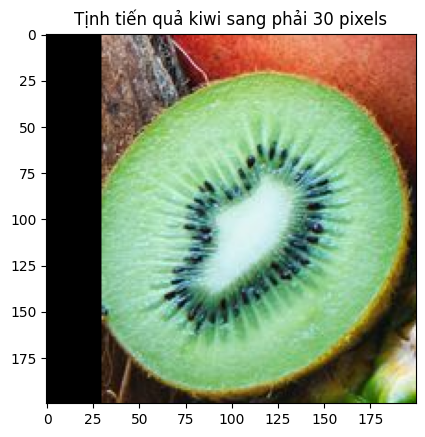

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as nd

data = iio.imread("exercise/colorful-ripe-tropical-fruits.jpg")
kiwi=data[900:1100, 400:600]

kiwi_shifted = nd.shift(kiwi, shift=(0, 30, 0))

iio.imsave("images/kiwi_shifted.jpg", kiwi_shifted.astype(np.uint8))
plt.title("Tịnh tiến quả kiwi sang phải 30 pixels")
plt.imshow(kiwi_shifted)
plt.show()

2. Viết chương trình chọn quả đu đủ và quả dưa hấu từ ảnh colorful-ripe-tropical-fruits.jpg trong thư mục exercise. Đổi màu hai đối tượng này.

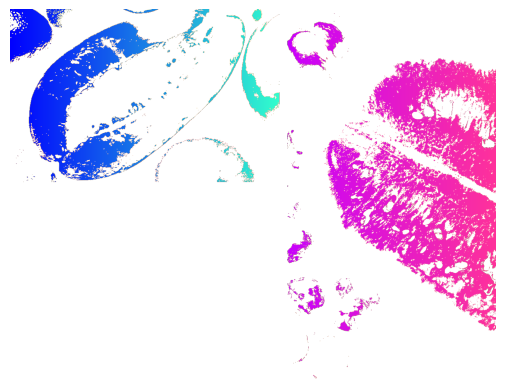

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio

data = iio.imread("exercise/colorful-ripe-tropical-fruits.jpg")
img_papaya = data[380:810, 80:750]     
img_watermelon = data[230:1150, 1600:]  

r, g, b = img_papaya[..., 0], img_papaya[..., 1], img_papaya[..., 2]
is_papaya = (r > 200) & (g > 100) & (b < 100)
h1, w1 = r.shape
grad_papaya = np.linspace(0, 1, w1)
grad_papaya = np.tile(grad_papaya, (h1, 1))
papaya_new = img_papaya.copy()
papaya_new = papaya_new.astype(float)
papaya_new[..., 0][is_papaya] = grad_papaya[is_papaya] * 50      
papaya_new[..., 1][is_papaya] = grad_papaya[is_papaya] * 255      
papaya_new[..., 2][is_papaya] = 255 - grad_papaya[is_papaya] * 50  
alpha_papaya = np.zeros((h1, w1), dtype=np.uint8)
alpha_papaya[is_papaya] = 255

r, g, b = img_watermelon[..., 0], img_watermelon[..., 1], img_watermelon[..., 2]
is_watermelon = (r > 150) & (g < 100) & (b < 100)
h2, w2 = r.shape
grad_watermelon = np.linspace(0, 1, w2)
grad_watermelon = np.tile(grad_watermelon, (h2, 1))
watermelon_new = img_watermelon.copy()
watermelon_new = watermelon_new.astype(float)
watermelon_new[..., 0][is_watermelon] = 200 + 55 * grad_watermelon[is_watermelon]    
watermelon_new[..., 1][is_watermelon] = 0 + 50 * grad_watermelon[is_watermelon]       
watermelon_new[..., 2][is_watermelon] = 255 - 100 * grad_watermelon[is_watermelon]   

alpha_watermelon = np.zeros((h2, w2), dtype=np.uint8)
alpha_watermelon[is_watermelon] = 255

H = max(h1, h2)
W = w1 + w2 + 20  
canvas = np.zeros((H, W, 4), dtype=np.uint8)

canvas[:h1, :w1, :3] = papaya_new[..., :3].astype(np.uint8)
canvas[:h1, :w1, 3] = alpha_papaya

canvas[:h2, w1+20:w1+20+w2, :3] = watermelon_new[..., :3].astype(np.uint8)
canvas[:h2, w1+20:w1+20+w2, 3] = alpha_watermelon
iio.imwrite("images/fruit_gradient_composite.png", canvas)
plt.imshow(canvas)
plt.axis('off')
plt.show()

3. Viết chương trình chọn ngọn núi và con thuyền từ ảnh quang_ninh.jpg trong thư mục exercise. Xoay 2 đối tượng này 1 góc 45 độ và lưu vào máy.

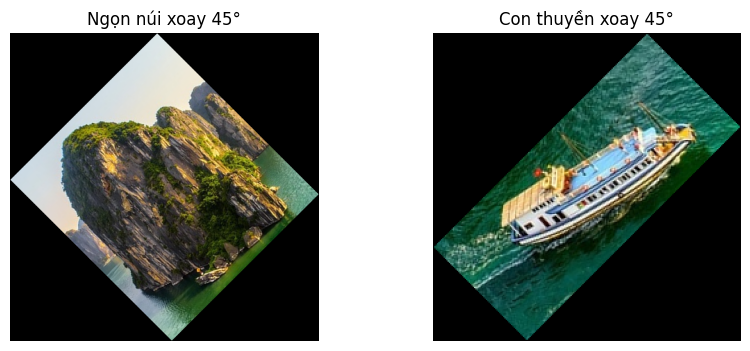

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as nd

data = iio.imread("exercise/quang_ninh.jpg")
mountain = data[10:340, 400:700] 
boat = data[450:550, 450:680]        
mountain_rot = nd.rotate(mountain, 45, reshape=True)
boat_rot = nd.rotate(boat, 45, reshape=True)

iio.imwrite("images/mountain_rotated.jpg", mountain_rot.astype(np.uint8))
iio.imwrite("images/boat_rotated.jpg", boat_rot.astype(np.uint8))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Ngọn núi xoay 45°")
plt.imshow(mountain_rot)
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Con thuyền xoay 45°")
plt.imshow(boat_rot)
plt.axis('off')
plt.show()

4. Viết chương trình chọn ngôi chùa từ ảnh pagoda.jpg trong thư mục exercise. Tăng kích thước ngôi chùa lên 5 lần và lưu vào máy.

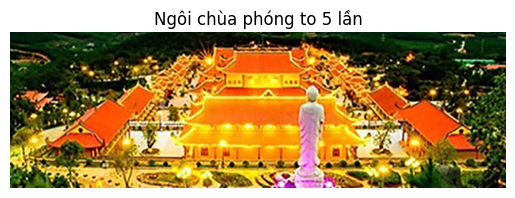

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as nd

data = iio.imread("exercise/pagoda.jpg")
pagoda = data[120:280, 10:520]
pagoda_zoomed = nd.zoom(pagoda, (5, 5, 1))

iio.imwrite("images/pagoda_zoomed.jpg", pagoda_zoomed.astype(np.uint8))
plt.title("Ngôi chùa phóng to 5 lần")
plt.imshow(pagoda_zoomed)
plt.axis('off')
plt.show()

5. Viết chương trình tạo menu
- Tịnh tiến
- Xoay
- Phóng to
- Thu nhỏ
- Coordinate Map
Khi chọn phím T, X, P, H, C thì hỏi muốn thực hiện trên hình nào từ 3 hình trong thư mục exercise. Người dùng chọn hình nào thì thực hiện phép biến đổi trên hình đó.

Menu:
T - Tịnh tiến
X - Xoay
P - Phóng to
H - Thu nhỏ
C - Coordinate Map (biến dạng sóng)
Chọn ảnh để thao tác:
1. colorful-ripe-tropical-fruits.jpg
2. quang_ninh.jpg
3. pagoda.jpg
Ảnh đã lưu vào images/menu_output.jpg


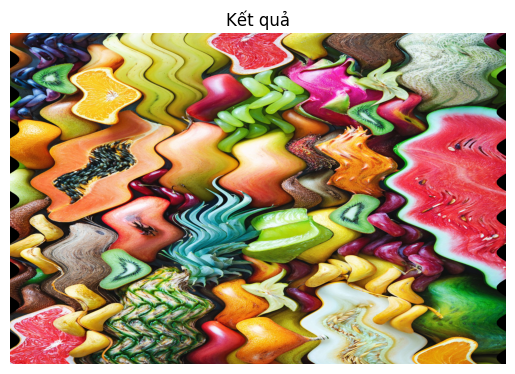

In [78]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pyplot as plt

def choose_image():
    print("Chọn ảnh để thao tác:")
    print("1. colorful-ripe-tropical-fruits.jpg")
    print("2. quang_ninh.jpg")
    print("3. pagoda.jpg")
    choice = input("Nhập số (1-3): ")
    files = {
        "1": "exercise/colorful-ripe-tropical-fruits.jpg",
        "2": "exercise/quang_ninh.jpg",
        "3": "exercise/pagoda.jpg"
    }
    return iio.imread(files.get(choice, "exercise/colorful-ripe-tropical-fruits.jpg"))

def translate(img):
    dx = int(input("Nhập số pixel tịnh tiến theo X: "))
    dy = int(input("Nhập số pixel tịnh tiến theo Y: "))
    return nd.shift(img, shift=(dy, dx, 0))

def rotate(img):
    angle = float(input("Nhập góc xoay (độ): "))
    reshape = input("Giữ nguyên kích thước? (y/n): ").strip().lower() != 'n'
    return nd.rotate(img, angle=angle, reshape=reshape)

def zoom(img, factor=None):
    if factor is None:
        factor = float(input("Nhập hệ số phóng to (>1) hoặc thu nhỏ (<1): "))
    return nd.zoom(img, zoom=(factor, factor, 1))

def coordinate_map(img):
    amplitude = float(input("Nhập biên độ sóng: "))
    h, w = img.shape[:2]
    Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    X_new = X + amplitude * np.sin(2 * np.pi * Y / 150)
    Y_new = Y
    coords = [Y_new.ravel(), X_new.ravel()]
    result = np.zeros_like(img)
    for i in range(img.shape[2]):
        result[..., i] = nd.map_coordinates(img[..., i], coords).reshape(h, w)
    return result

def main():
    print("Menu:")
    print("T - Tịnh tiến")
    print("X - Xoay")
    print("P - Phóng to")
    print("H - Thu nhỏ")
    print("C - Coordinate Map (biến dạng sóng)")
    op = input("\nChọn phép biến đổi (T/X/P/H/C): ").strip().upper()
    img = choose_image()

    if op == "T":
        result = translate(img)
    elif op == "X":
        result = rotate(img)
    elif op == "P":
        result = zoom(img)
    elif op == "H":
        factor = float(input("Nhập hệ số thu nhỏ (<1): "))
        result = zoom(img, factor)
    elif op == "C":
        result = coordinate_map(img)
    else:
        print("Lựa chọn không hợp lệ.")
        return

    iio.imwrite("images/menu_output.jpg", result.astype(np.uint8))
    print("Ảnh đã lưu vào images/menu_output.jpg")
    plt.imshow(result)
    plt.axis('off')
    plt.title("Kết quả")
    plt.show()

if __name__ == "__main__":
    main()